In [ ]:
import torch 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
import os
outdir = r"C:\Document\Serieux\Travail\python_work\cEBNM_torch\notebooks\cEBMF_test\hierarchical_factor_model"
from pathlib import Path

outdir_sim = Path(
    r"C:\Document\Serieux\Travail\python_work\cEBNM_torch\notebooks"
    r"\cEBMF_test\hierarchical_factor_model\sim_mat"
)


outdir_sim2 = Path(
    r"C:/Document/Serieux/Travail/Data_analysis_and_papers/bencmark_cebmf/cEBMF_sim_and_fit"
)
outdir_sim.mkdir(parents=True, exist_ok=True)
 
os.makedirs(outdir_sim, exist_ok=True)
os.makedirs(outdir, exist_ok=True)
# Reproducibility
from cebmf_torch import cEBMF

In [2]:
i=1

In [ ]:
import numpy as np

def reconstruction_rmse(L_est, F_est, X_true):
    """RMSE between reconstructed signal L_est @ F_est and the true noiseless signal."""
    X_hat = (L_est @ F_est).detach().cpu().numpy()
    X_true_np = X_true.detach().cpu().numpy()
    return np.sqrt(np.mean((X_hat - X_true_np) ** 2))

res_no_warm = list()
res_warm = list()

rmse_no_warm_cold = list()   # mycebmf2 (cgb_sharp_2, no warm start)
rmse_no_warm_warm = list()   # mycebmf21 (cgb_sharp_2, warm-started from mycebmf1)

for i in range(10):
    N = 2000
    P = 200
    torch.manual_seed(i)

    t0 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t1 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t2 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t11 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t12 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t21 = torch.randint(0, 2, (P,), dtype=torch.float32)
    t22 = torch.randint(0, 2, (P,), dtype=torch.float32)

    a0 = t0 * torch.randn(P)
    b1 = t1 * torch.randn(P)
    b2 = t2 * torch.randn(P)
    detla11 = t11 * torch.randn(P)
    detla12 = t11 * torch.randn(P)
    detla21 = t11 * torch.randn(P)
    detla22 = t11 * torch.randn(P)

    f_mat = torch.stack([a0, b1, b2, detla11, detla12, detla21, detla22], dim=0)

    N = 1000
    L = torch.zeros(N, 7, dtype=torch.float32)
    L[:, 0] = 1
    L[0:500, 1] = 1
    L[500:, 2] = 1
    L[0:250, 3] = 1
    L[251:500, 4] = 1
    L[501:750, 5] = 1
    L[751:, 6] = 1

    X_true = L @ f_mat
    Z = L @ f_mat + 0.5 * torch.randn(N, P) * 2.5
    Z_np = Z.detach().cpu().numpy()

    X_np = X_true.detach().cpu().numpy()
# Save as tab-delimited text
    #np.savetxt(os.path.join(outdir, "Z_matrix.txt"), Z_np, fmt="%.6f", delimiter="\t")
  

# Save as tab-delimited text
    np.savetxt(
    outdir_sim / f"Z_matrix_{i}.txt",
    Z_np,
    fmt="%.6f",
    delimiter="\t"
    )

    np.savetxt(
    outdir_sim2 / f"Z_matrix_{i}.txt",
    Z_np,
    fmt="%.6f",
    delimiter="\t"
    )

    np.savetxt(
    outdir_sim / f"X_matrix_{i}.txt",
    X_np,
    fmt="%.6f",
    delimiter="\t"
    )
    np.savetxt(
    outdir_sim2 / f"X_matrix_{i}.txt",
    X_np,
    fmt="%.6f",
    delimiter="\t"
    )    
    # --- cold start ---
    mycebmf2 = cEBMF(data=Z, self_row_cov=True,
                      prior_L="cgb_sharp", K=10,
                      allow_backfitting=False)
    mycebmf2.initialise_factors()
    mycebmf2.fit(10)
    res_no_warm.append(mycebmf2.L)
    rmse_no_warm_cold.append(  torch.sqrt(torch.mean( (X_true -mycebmf2.L@  mycebmf2.F.T)**2)))
  

    # --- short cgb run used only to warm-start ---
    mycebmf1 = cEBMF(data=Z, self_row_cov=True,
                      prior_L="cgb", K=10,
                      allow_backfitting=False)
    mycebmf1.initialise_factors()
    mycebmf1.fit(10)

    # --- warm start ---
    mycebmf21 = cEBMF(data=Z, self_row_cov=True,
                       prior_L="cgb_sharp_2", K=10,
                       allow_backfitting=False)
    mycebmf21.initialise_factors(L=mycebmf1.L, F=mycebmf1.F)
    mycebmf21.fit(10)
    res_no_warm.append(mycebmf21.L)   # kept to match your original code
    res_warm.append(mycebmf21.L)
    rmse_no_warm_warm.append(torch.sqrt(  torch.mean( (X_true -mycebmf21.L@  mycebmf21.F.T)**2)))



    np.savetxt(
    outdir_sim2 / f"L_cebmf_{i}.txt",
    mycebmf21.L,
    fmt="%.6f",
    delimiter="\t"
    )

    np.savetxt(
    outdir_sim2 / f"fit_cebmf_{i}.txt",
    mycebmf21.L@  mycebmf21.F.T.L,
    fmt="%.6f",
    delimiter="\t"
    )    
    print(i)
    print( rmse_no_warm_warm)

    print( rmse_no_warm_cold)
    
rmse_no_warm_cold = torch.stack(rmse_no_warm_cold)
rmse_no_warm_warm = torch.stack(rmse_no_warm_warm)



[CGB] Epoch 10/10, Loss=38.9677, mu2=-0.080, sigma2=0.904
[CGB] Epoch 10/10, Loss=24.2861, mu2=-0.029, sigma2=0.628
[CGB] Epoch 10/10, Loss=10.3160, mu2=0.060, sigma2=0.378
[CGB] Epoch 10/10, Loss=8.6771, mu2=0.015, sigma2=0.347
[CGB] Epoch 10/10, Loss=2.2253, mu2=0.002, sigma2=0.084
[CGB] Epoch 10/10, Loss=2.2062, mu2=0.005, sigma2=0.094
[CGB] Epoch 10/10, Loss=2.1898, mu2=0.001, sigma2=0.115
[CGB] Epoch 10/10, Loss=2.1747, mu2=0.016, sigma2=0.088
[CGB] Epoch 10/10, Loss=2.1590, mu2=0.003, sigma2=0.117
[CGB] Epoch 10/10, Loss=2.1376, mu2=-0.003, sigma2=0.097
[CGB] Epoch 10/10, Loss=32.4029, mu2=-0.160, sigma2=0.324
[CGB] Epoch 10/10, Loss=19.5668, mu2=-0.069, sigma2=0.148
[CGB] Epoch 10/10, Loss=5.7761, mu2=0.143, sigma2=0.048
[CGB] Epoch 10/10, Loss=4.7282, mu2=0.109, sigma2=0.035
[CGB] Epoch 10/10, Loss=2.1336, mu2=0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.2538, mu2=-0.001, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.4028, mu2=0.000, sigma2=0.000
[CGB] Epoch 10/10, Loss=2.3748, mu2=0

In [4]:
 

print(f"Cold start RMSE:  mean={rmse_no_warm_cold.mean():.4f}, sd={rmse_no_warm_cold.std():.4f}")
print(f"Warm start RMSE:  mean={rmse_no_warm_warm.mean():.4f}, sd={rmse_no_warm_warm.std():.4f}")

Cold start RMSE:  mean=0.1066, sd=0.0323
Warm start RMSE:  mean=0.0824, sd=0.0020


In [5]:
print(f"Cold start RMSE:  mean={rmse_no_warm_cold.mean():.4f}, sd={rmse_no_warm_cold.std():.4f}")
print(f"Warm start RMSE:  mean={rmse_no_warm_warm.mean():.4f}, sd={rmse_no_warm_warm.std():.4f}")

Cold start RMSE:  mean=0.1066, sd=0.0323
Warm start RMSE:  mean=0.0824, sd=0.0020


In [6]:
torch.sqrt(torch.mean( (X_true -mycebmf2.L@  mycebmf2.F.T)**2))

tensor(0.0976)

In [7]:
i=1

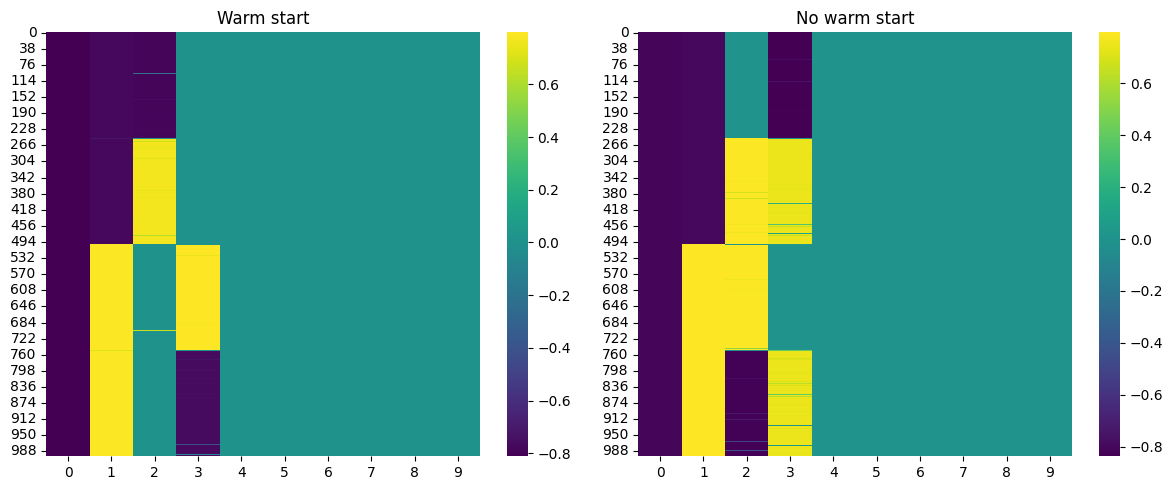

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    res_warm[i],
    cmap="viridis",
    annot=False,
    ax=axes[0]
)
axes[0].set_title("Warm start")

# Second heatmap
sns.heatmap(
     res_no_warm[i],
    cmap="viridis",
    annot=False,
    ax=axes[1]
)
axes[1].set_title("No warm start")

plt.tight_layout()
plt.show()
i=i+1

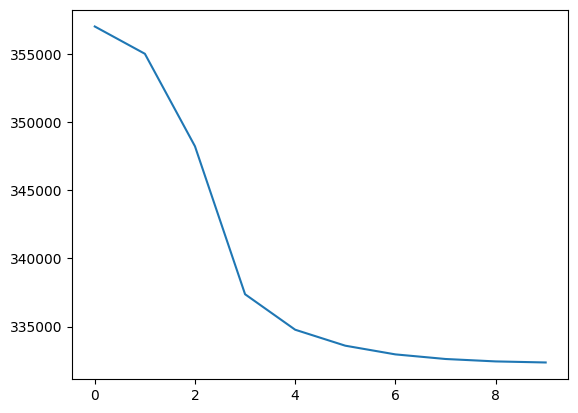

In [9]:
plt.plot(mycebmf2.obj)